In [1]:
# %%

import sys
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.inspection import permutation_importance
import itertools
import pandas as pd
import numpy as np
import time
import sys
from prepare_trainingdata import prepare_data
from train_evaluate import train_and_evaluate_model
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, auc
import seaborn as sns
import random
# random.seed(42)

In [2]:
# %%

def bootstrap(features, n_bootstraps):
    """
    Perform bootstrapping on the provided dataset.

    Parameters:
        df (pd.DataFrame): The input dataframe containing the dataset.
        features (list): List of feature columns.
        n_bootstraps (int): Number of bootstraps to perform.

    Returns:
        list: A list containing the results of each bootstrap.
    """
    groups = list(range(1, 12)) * 2  # Duplicating group range to cover 22 assignments
      # Shuffle to randomize distribution
    chromosomes = [
        'chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9',
        'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17',
        'chr18', 'chr19', 'chr20','chr21', 'chr22'
    ]

    df = pd.read_csv('/Users/edatkinson/Repos/Modelling/merged_annotated_data.csv', sep=',')
    
    df.drop(columns=['merged', 'WTtrinuc', 'mutTrinuc'], inplace=True)
    df.replace(np.nan, 0, inplace=True)
    boot_results = []
    for _ in range(n_bootstraps):
        random.shuffle(groups)
        chromosome_to_group = dict(zip(chromosomes, groups))
        df['grouping'] = df['chrom'].map(chromosome_to_group)
        
        metrics = {
            "accuracy": [],
            "precision": [],
            "recall": [],
            "f1": [],
        }

        X_train_val, y_train_val, groups_train_val, X_test, y_test, groups_test = prepare_data(df, features)


        metrics, final_model, test_results, actual_predicted = train_and_evaluate_model(
            XGBClassifier(random_state=42), X_train_val, y_train_val, groups_train_val, X_test, y_test
        )
        y_test_pred_proba = final_model.predict_proba(X_test)[:, 1]

        y_pred = final_model.predict(X_test)
        confidence = get_confidence(y_test_pred_proba)

        actual_predicted_df = pd.DataFrame({
            'actual': y_test,
            'predicted': y_pred,
            'probability': y_test_pred_proba,
            'confidence': confidence[0],
            'entropy': confidence[1]
        })
    
        boot_results.append(actual_predicted_df)

    metrics_list = []
    for res in boot_results:

        metrics_list.append({
            "accuracy": accuracy_score(res['actual'], res['predicted']),
            "precision": precision_score(res['actual'], res['predicted']),
            "recall": recall_score(res['actual'], res['predicted']),
            "f1": f1_score(res['actual'], res['predicted']),
            "confidence" : res['confidence'],
            "entropy" : res['entropy']
        })
    
    ci = {
        'mean': [],
        'std': []
    }
    for metric in metrics_list:
        ci['mean'].append(metric['confidence'].mean())
        ci['std'].append(metric['confidence'].std())
    
    
    return ci, metrics_list





def get_confidence(probs):
    # confidence = np.abs(probs-0.5) * 2
    confidence = np.maximum(probs, 1-probs)

    probs_safe = np.clip(probs, 1e-10, 1 - 1e-10)
    h_p = -probs_safe * np.log2(probs_safe) - (1 - probs_safe) * np.log2(1 - probs_safe)
    entrpy = 1 - h_p  # Simplified since np.log2(2) = 1
    
    return confidence, entrpy

def calibrate_confidence(probs):
    conf, entr = get_confidence(probs)




def train_classifier(df, features=None, classifier=None, feature_importance=False, boot=False, roc=False):
    """
    Train a classifier on the provided dataset.

    Parameters:
        df (pd.DataFrame): The input dataframe containing the dataset.
        features (list, optional): List of feature columns. If None, default columns are used. Default is None.
        classifier: Classifier object. If None, a default classifier is used.
    Returns:
        tuple: A tuple containing actual_predicted_targets, results_df, final_model_tuple, and results_tuple.

        
    """
    params = {
        "learning_rate": 0.2,
        "max_depth": 5,
        "n_estimators": 200,
        "reg_alpha": 0,
        "subsample": 1.0
    }
    if classifier is None:
        classifier = XGBClassifier(n_estimators=200, learning_rate = 0.2, max_depth=5, reg_alpha='0', subsample=1,random_state=42)

    X_train_val, y_train_val, groups_train_val, X_test, y_test, groups_test = prepare_data(df, features)

    # if boot == True:
    #     bootstrap_res= bootstrap(df, features, 10)

    start = time.time()
    metrics, final_model, test_results, actual_predicted = train_and_evaluate_model(
        classifier, X_train_val, y_train_val, groups_train_val, X_test, y_test
    )
    end = time.time()
    total_time = end - start
    test_results["time"] = format(total_time, ".3f")

    # sampler = RandomUnderSampler(random_state=42)
    # X_test, y_test = sampler.fit_resample(X_test, y_test)
    
    # Prepare final_model tuple with the model and list of feature columns
    final_model_tuple = (final_model, X_test.columns.tolist())
    y_test_pred_proba = final_model.predict_proba(X_test)[:, 1]

    y_pred = final_model.predict(X_test)
    confidence = get_confidence(y_test_pred_proba)

    actual_predicted_df = pd.DataFrame({
        'actual': y_test,
        'predicted': y_pred,
        'probability': y_test_pred_proba,
        'confidence': confidence[0],
        'entropy': confidence[1]
    })

    if roc == True:
        fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)
        roc_auc = roc_auc_score(y_test, y_test_pred_proba)

        plt.rcParams['text.usetex'] = False  # Disable LaTeX rendering

        # Plot ROC Curve
        plt.figure()
        plt.plot(fpr, tpr, label=r'ROC Curve (AUC = {:.3f})'.format(roc_auc))
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel("False Positive Rate", fontsize=16)  # Adjust x-label font size
        plt.ylabel("True Positive Rate", fontsize=16)  # Adjust y-label font size
        plt.legend(loc="lower right", fontsize=16)  # Set legend font size here
        plt.show()

        print(f"ROC AUC Score: {roc_auc}")

    # Prepare results tuple with validation_results and test_results
    validation_results = pd.DataFrame(metrics)

    results_tuple = (validation_results, test_results)

    
    if feature_importance:
        # Extract feature importance
        if isinstance(classifier, XGBClassifier):
            feature_importance = final_model.get_booster().get_score(importance_type="weight")
            feature_importance = pd.DataFrame(feature_importance.items()).sort_values(1, ascending=False)
            feature_importance.columns = ["feature", "importance"]
        else:
            # Calculate permutation importance
            perm_importance = permutation_importance(final_model, X_test, y_test, n_repeats=30, random_state=42)
            # Get the feature importance scores
            feature_importance = pd.DataFrame(
                {"feature": X_test.columns, "importance": perm_importance["importances_mean"]}
            )
            feature_importance = feature_importance.sort_values(by="importance", ascending=False)
    else:
        feature_importance = np.nan

    return (actual_predicted, actual_predicted_df), feature_importance, final_model_tuple, results_tuple

In [23]:
# %%

groups = list(range(1, 12)) *2   # Duplicating group range to cover 22 assignments
random.shuffle(groups)  # Shuffle to randomize distribution
chromosomes = [
    'chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9',
    'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17',
    'chr18', 'chr19', 'chr20','chr21', 'chr22'
]
chromosome_to_group = dict(zip(chromosomes, groups))

df = pd.read_csv('/Users/edatkinson/Repos/Modelling/data/pmed_inframe.csv', sep=',')
df['grouping'] = df['chrom'].map(chromosome_to_group)

df.drop(columns=['WTtrinuc', 'mutTrinuc', 'genes'], inplace=True)
# df.replace(np.nan, 0, inplace=True)
alphaFold = ['X_coordinate','Y_coordinate','Z_coordinate','atom_site_occupancy','isotropic_temperature']
dna_shape = [
    '3_MGW', '4_MGW', '5_MGW', '6_MGW', '7_MGW', '8_MGW', '9_MGW', '10_MGW', '11_MGW', '12_MGW', 
    '13_MGW', '14_MGW', '15_MGW', '16_MGW', '17_MGW', '18_MGW', '2_HelT', '3_HelT', '4_HelT', '5_HelT', 
    '6_HelT', '7_HelT', '8_HelT', '9_HelT', '10_HelT', '11_HelT', '12_HelT', '13_HelT', '14_HelT', 
    '15_HelT', '16_HelT', '17_HelT', '18_HelT', '3_ProT', '4_ProT', '5_ProT', '6_ProT', '7_ProT', 
    '8_ProT', '9_ProT', '10_ProT', '11_ProT', '12_ProT', '13_ProT', '14_ProT', '15_ProT', '16_ProT', 
    '17_ProT', '18_ProT', '2_Roll_x', '3_Roll_x', '4_Roll_x', '5_Roll', '6_Roll', '7_Roll', '8_Roll', 
    '9_Roll', '10_Roll', '11_Roll', '12_Roll', '13_Roll', '14_Roll', '15_Roll', '16_Roll', '17_Roll', 
    '18_Roll', '3_EP', '4_EP', '5_EP', '6_EP', '7_EP', '8_EP', '9_EP', '10_EP', '11_EP', '12_EP', 
    '13_EP', '14_EP', '15_EP', '16_EP', '17_EP', '18_EP'
]
gcContent = [
    '20GCContent', '20CpGCount', '20CpG_obs_exp',
    '40GCContent', '40CpGCount', '40CpG_obs_exp',
    '60GCContent', '60CpGCount', '60CpG_obs_exp',
    '80GCContent', '80CpGCount', '80CpG_obs_exp',
    '100GCContent', '100CpGCount', '100CpG_obs_exp',
    '200GCContent', '200CpGCount', '200CpG_obs_exp',
    '500GCContent', '500CpGCount', '500CpG_obs_exp',
    '1000GCContent', '1000CpGCount', '1000CpG_obs_exp',
    '2000GCContent', '2000CpGCount', '2000CpG_obs_exp'
]

cons_features = ['phyloP20way','k36.Bismap.MultiTrackMappability','k50.Bismap.MultiTrackMappability',
                 'phyloP30way','phyloP17way','phyloP100way','phastCons470way','k24.Umap.MultiTrackMappability',
                 'phyloP7way','phastCons20way','k100.Umap.MultiTrackMappability','phyloP470way','k50.Umap.MultiTrackMappability',
                 'phastCons100way','phastCons17way','phastCons30way','k36.Umap.MultiTrackMappability','phastCons7way',
                 'k24.Bismap.MultiTrackMappability','k100.Bismap.MultiTrackMappability','phyloP4way','phastCons4way'
            ]

dna_props = [
    '1_Bend', '1_Tip', '1_Inclination', '1_Major_Groove_Width', '1_Major_Groove_Depth',
    '1_Major_Groove_Size', '1_Major_Groove_Distance', '1_Minor_Groove_Width', '1_Minor_Groove_Depth',
    '1_Minor_Groove_Size', '1_Minor_Groove_Distance', '1_Persistance_Length',
    '1_Probability_contacting_nucleosome_core', '1_Mobility_to_bend_towards_major_groove',
    '1_Mobility_to_bend_towards_minor_groove', '1_Propeller_Twist', '1_Clash_Strength', '1_Shift_(RNA)',
    '1_Hydrophilicity_(RNA)', '1_Twist_(DNA-protein_complex)', '1_Twist_twist', '1_Tilt_tilt', '1_Roll_roll',
    '1_Twist_tilt', '1_Twist_roll', '1_Tilt_roll', '1_Shift_shift', '1_Slide_slide', '1_Rise_rise',
    '1_Shift_slide', '1_Shift_rise', '1_Slide_rise', '1_Twist_shift', '1_Twist_slide', '1_Twist_rise',
    '1_Tilt_shift', '1_Tilt_slide', '1_Tilt_rise', '1_Roll_shift', '1_Roll_slide', '1_Roll_rise',
    '1_Slide_stiffness', '1_Shift_stiffness', '1_Roll_stiffness', '1_Tilt_stiffness', '1_Twist_stiffness',
    '1_GC_content', '1_Purine_(AG)_content', '1_Keto_(GT)_content', '1_Adenine_content', '1_Guanine_content',
    '1_Cytosine_content', '1_Thymine_content', '1_Tilt_(DNA-protein_complex)', '1_Roll_(DNA-protein_complex)',
    '1_Shift_(DNA-protein_complex)', '1_Slide_(DNA-protein_complex)', '1_Rise_(DNA-protein_complex)', '1_Shift',
    '1_Slide', '1_Rise', '1_Wedge', '1_Direction', '1_Slide_(RNA)', '1_Rise_(RNA)', '1_Tilt_(RNA)',
    '1_Roll_(RNA)', '1_Twist_(RNA)', '1_Stacking_energy_(RNA)', '1_Rise_stiffness', '1_Melting_Temperature',
    '1_Stacking_energy', '1_Free_energy_(RNA)', '1_Enthalpy_(RNA)', '1_Entropy_(RNA)', '1_Tilt', '1_Roll',
    '1_Twist', '1_Flexibility_slide', '1_Flexibility_shift', '1_Enthalpy', '1_Entropy', '1_Free_energy',
    '2_Bend', '2_Tip', '2_Inclination', '2_Major_Groove_Width', '2_Major_Groove_Depth', '2_Major_Groove_Size',
    '2_Major_Groove_Distance', '2_Minor_Groove_Width', '2_Minor_Groove_Depth', '2_Minor_Groove_Size',
    '2_Minor_Groove_Distance', '2_Persistance_Length',
    '2_Probability_contacting_nucleosome_core', '2_Mobility_to_bend_towards_major_groove',
    '2_Mobility_to_bend_towards_minor_groove', '2_Propeller_Twist', '2_Clash_Strength', '2_Shift_(RNA)',
    '2_Hydrophilicity_(RNA)', '2_Twist_(DNA-protein_complex)', '2_Twist_twist', '2_Tilt_tilt', '2_Roll_roll',
    '2_Twist_tilt', '2_Twist_roll', '2_Tilt_roll', '2_Shift_shift', '2_Slide_slide', '2_Rise_rise',
    '2_Shift_slide', '2_Shift_rise', '2_Slide_rise', '2_Twist_shift', '2_Twist_slide', '2_Twist_rise',
    '2_Tilt_shift', '2_Tilt_slide', '2_Tilt_rise', '2_Roll_shift', '2_Roll_slide', '2_Roll_rise',
    '2_Slide_stiffness', '2_Shift_stiffness', '2_Roll_stiffness', '2_Tilt_stiffness', '2_Twist_stiffness',
    '2_GC_content', '2_Purine_(AG)_content', '2_Keto_(GT)_content', '2_Adenine_content', '2_Guanine_content',
    '2_Cytosine_content', '2_Thymine_content', '2_Tilt_(DNA-protein_complex)', '2_Roll_(DNA-protein_complex)',
    '2_Shift_(DNA-protein_complex)', '2_Slide_(DNA-protein_complex)', '2_Rise_(DNA-protein_complex)', '2_Shift',
    '2_Slide', '2_Rise', '2_Wedge', '2_Direction', '2_Slide_(RNA)', '2_Rise_(RNA)', '2_Tilt_(RNA)',
    '2_Roll_(RNA)', '2_Twist_(RNA)', '2_Stacking_energy_(RNA)', '2_Rise_stiffness', '2_Melting_Temperature',
    '2_Stacking_energy', '2_Free_energy_(RNA)', '2_Enthalpy_(RNA)', '2_Entropy_(RNA)', '2_Tilt', '2_Roll_y',
    '2_Twist', '2_Flexibility_slide', '2_Flexibility_shift', '2_Enthalpy', '2_Entropy', '2_Free_energy',
    '3_Bend', '3_Tip', '3_Inclination', '3_Major_Groove_Width', '3_Major_Groove_Depth', '3_Major_Groove_Size',
    '3_Major_Groove_Distance', '3_Minor_Groove_Width', '3_Minor_Groove_Depth', '3_Minor_Groove_Size',
    '3_Minor_Groove_Distance', '3_Persistance_Length', '3_Probability_contacting_nucleosome_core',
    '3_Mobility_to_bend_towards_major_groove', '3_Mobility_to_bend_towards_minor_groove', '3_Propeller_Twist',
    '3_Clash_Strength', '3_Shift_(RNA)', '3_Hydrophilicity_(RNA)', '3_Twist_(DNA-protein_complex)',
    '3_Twist_twist', '3_Tilt_tilt', '3_Roll_roll', '3_Twist_tilt', '3_Twist_roll', '3_Tilt_roll',
    '3_Shift_shift', '3_Slide_slide', '3_Rise_rise', '3_Shift_slide', '3_Shift_rise', '3_Slide_rise',
    '3_Twist_shift', '3_Twist_slide', '3_Twist_rise', '3_Tilt_shift', '3_Tilt_slide', '3_Tilt_rise',
    '3_Roll_shift', '3_Roll_slide', '3_Roll_rise', '3_Slide_stiffness', '3_Shift_stiffness', '3_Roll_stiffness',
    '3_Tilt_stiffness', '3_Twist_stiffness', '3_GC_content', '3_Purine_(AG)_content', '3_Keto_(GT)_content',
    '3_Adenine_content', '3_Guanine_content', '3_Cytosine_content', '3_Thymine_content',
    '3_Tilt_(DNA-protein_complex)', '3_Roll_(DNA-protein_complex)', '3_Shift_(DNA-protein_complex)',
    '3_Slide_(DNA-protein_complex)', '3_Rise_(DNA-protein_complex)', '3_Shift', '3_Slide', '3_Rise',
    '3_Wedge', '3_Direction', '3_Slide_(RNA)', '3_Rise_(RNA)', '3_Tilt_(RNA)', '3_Roll_(RNA)', '3_Twist_(RNA)',
    '3_Stacking_energy_(RNA)', '3_Rise_stiffness', '3_Melting_Temperature', '3_Stacking_energy',
    '3_Free_energy_(RNA)', '3_Enthalpy_(RNA)', '3_Entropy_(RNA)', '3_Tilt', '3_Roll_y', '3_Twist',
    '3_Flexibility_slide', '3_Flexibility_shift', '3_Enthalpy', '3_Entropy', '3_Free_energy',
    '4_Bend', '4_Tip', '4_Inclination', '4_Major_Groove_Width', '4_Major_Groove_Depth', '4_Major_Groove_Size',
    '4_Major_Groove_Distance', '4_Minor_Groove_Width', '4_Minor_Groove_Depth', '4_Minor_Groove_Size',
    '4_Minor_Groove_Distance', '4_Persistance_Length', '4_Probability_contacting_nucleosome_core',
    '4_Mobility_to_bend_towards_major_groove', '4_Mobility_to_bend_towards_minor_groove', '4_Propeller_Twist',
    '4_Clash_Strength', '4_Shift_(RNA)', '4_Hydrophilicity_(RNA)', '4_Twist_(DNA-protein_complex)',
    '4_Twist_twist', '4_Tilt_tilt', '4_Roll_roll', '4_Twist_tilt', '4_Twist_roll', '4_Tilt_roll',
    '4_Shift_shift', '4_Slide_slide', '4_Rise_rise', '4_Shift_slide', '4_Shift_rise', '4_Slide_rise',
    '4_Twist_shift', '4_Twist_slide', '4_Twist_rise', '4_Tilt_shift', '4_Tilt_slide', '4_Tilt_rise',
    '4_Roll_shift', '4_Roll_slide', '4_Roll_rise', '4_Slide_stiffness', '4_Shift_stiffness', '4_Roll_stiffness',
    '4_Tilt_stiffness', '4_Twist_stiffness', '4_GC_content', '4_Purine_(AG)_content', '4_Keto_(GT)_content',
    '4_Adenine_content', '4_Guanine_content', '4_Cytosine_content', '4_Thymine_content',
    '4_Tilt_(DNA-protein_complex)', '4_Roll_(DNA-protein_complex)', '4_Shift_(DNA-protein_complex)',
    '4_Slide_(DNA-protein_complex)', '4_Rise_(DNA-protein_complex)', '4_Shift', '4_Slide', '4_Rise', '4_Wedge',
    '4_Direction', '4_Slide_(RNA)', '4_Rise_(RNA)', '4_Tilt_(RNA)', '4_Roll_(RNA)', '4_Twist_(RNA)',
    '4_Stacking_energy_(RNA)', '4_Rise_stiffness', '4_Melting_Temperature', '4_Stacking_energy',
    '4_Free_energy_(RNA)', '4_Enthalpy_(RNA)', '4_Entropy_(RNA)', '4_Tilt', '4_Roll_y', '4_Twist',
    '4_Flexibility_slide', '4_Flexibility_shift', '4_Enthalpy', '4_Entropy', '4_Free_energy'
]

driver_stat
0    133
1    133
Name: count, dtype: int64
driver_stat
0    137
1    137
Name: count, dtype: int64
driver_stat
0    166
1    166
Name: count, dtype: int64
driver_stat
0    170
1    170
Name: count, dtype: int64
driver_stat
0    151
1    151
Name: count, dtype: int64
driver_stat
0    172
1    172
Name: count, dtype: int64
driver_stat
0    165
1    165
Name: count, dtype: int64
driver_stat
0    149
1    149
Name: count, dtype: int64
driver_stat
0    166
1    166
Name: count, dtype: int64
driver_stat
0    166
1    166
Name: count, dtype: int64


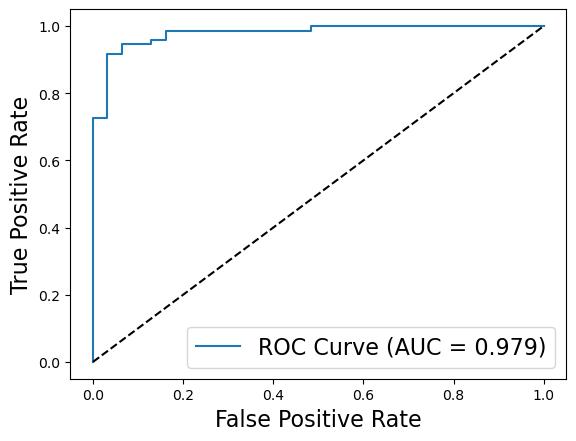

ROC AUC Score: 0.9792311091471498
     actual  predicted  probability  confidence   entropy
44        0          0     0.000602    0.999398  0.992691
125       0          0     0.000211    0.999789  0.997124
143       1          1     0.996410    0.996410  0.965674
145       1          1     0.931578    0.931578  0.639993
146       1          1     0.997263    0.997263  0.972754
..      ...        ...          ...         ...       ...
766       0          0     0.012938    0.987062  0.900308
808       0          0     0.230175    0.769825  0.221684
811       0          0     0.010544    0.989456  0.915620
862       0          0     0.014924    0.985076  0.888100
873       0          0     0.007356    0.992644  0.937299

[104 rows x 5 columns] 

   accuracy  precision    recall        f1               roc_auc  \
0  0.901818   0.972477  0.909871  0.940133  [0.9581034130390352]   
1  0.840741   0.989637  0.823276  0.898824  [0.9550816696914701]   
2  0.910569   1.000000  0.907173  0.9513

In [37]:
# %%

actual_predicted, feature_importance, final_model_tuple, results_tuple = train_classifier(df, features=None, classifier=None, feature_importance=True, boot=False, roc=True)
# bootstrap_res, confidence
print(actual_predicted[1], '\n')
print(results_tuple[0], '\n')
print(results_tuple[1], '\n')

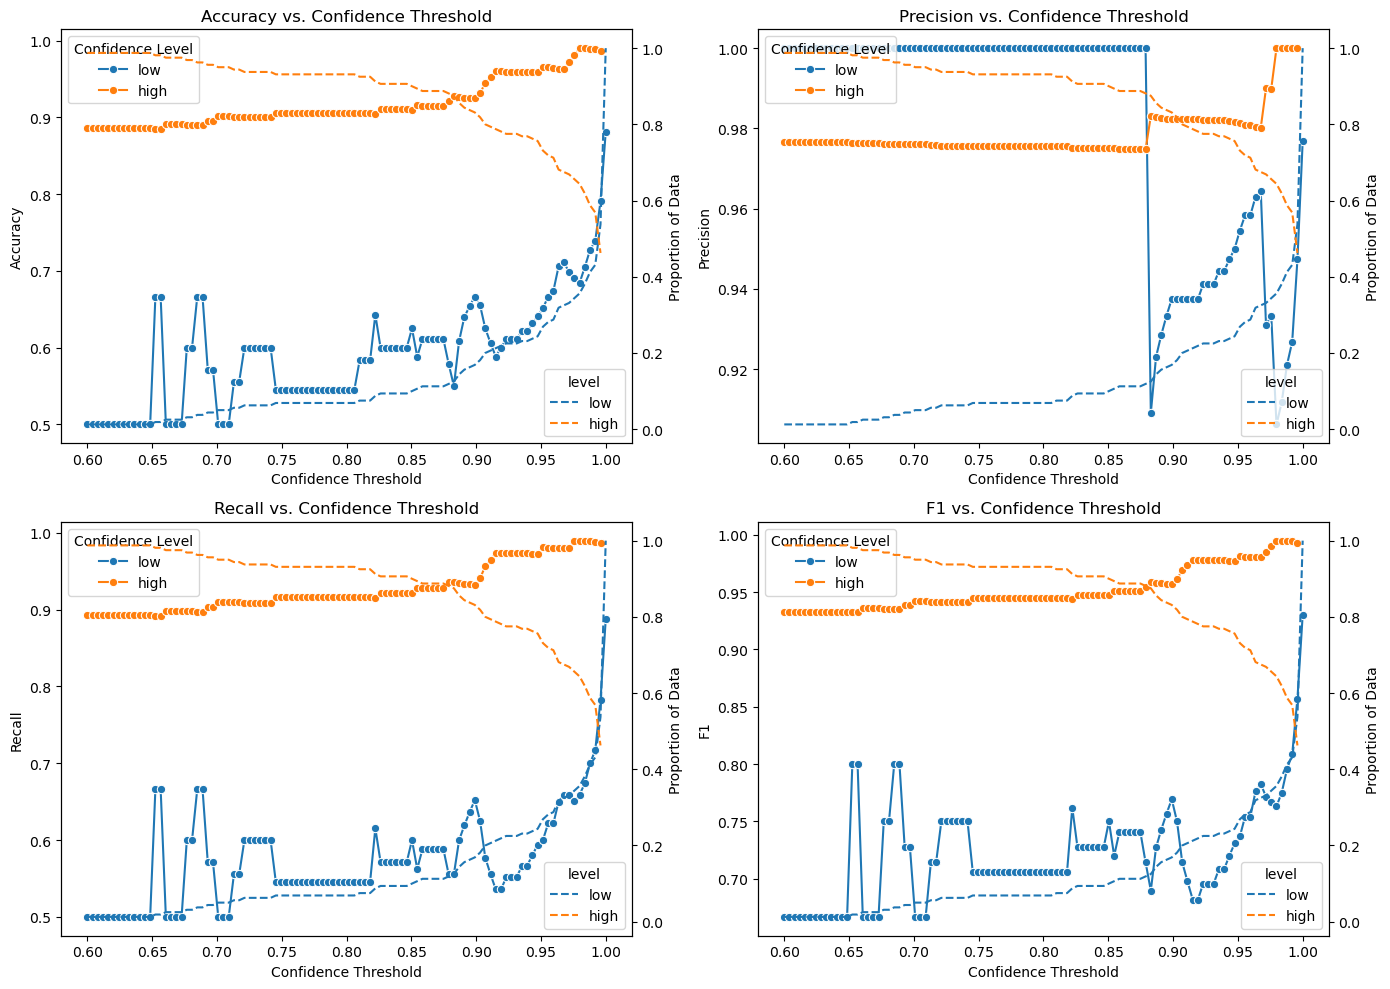

In [16]:
confidence_data = actual_predicted[1]


def confidence_analysis(confidence_data, intervals=100):
    sig_levels = np.linspace(0.6, 1, intervals)
    
    metrics_list = []
    
    for sl in sig_levels:
        low_confidence = confidence_data[confidence_data['confidence'] < sl]
        high_confidence = confidence_data[confidence_data['confidence'] >= sl]

        if len(low_confidence) > 0:
            metrics_list.append({
                "sig_level": sl,
                "level": "low",
                "accuracy": accuracy_score(low_confidence['actual'], low_confidence['predicted']),
                "precision": precision_score(low_confidence['actual'], low_confidence['predicted']),
                "recall": recall_score(low_confidence['actual'], low_confidence['predicted']),
                "f1": f1_score(low_confidence['actual'], low_confidence['predicted']),
                "proportion": len(low_confidence) / len(confidence_data)
            })

        if len(high_confidence) > 0:
            metrics_list.append({
                "sig_level": sl,
                "level": "high",
                "accuracy": accuracy_score(high_confidence['actual'], high_confidence['predicted']),
                "precision": precision_score(high_confidence['actual'], high_confidence['predicted']),
                "recall": recall_score(high_confidence['actual'], high_confidence['predicted']),
                "f1": f1_score(high_confidence['actual'], high_confidence['predicted']),
                "proportion": len(high_confidence) / len(confidence_data)
            })
    
    return pd.DataFrame(metrics_list)

confidence_metrics = confidence_analysis(confidence_data, intervals=100)


def plot_metrics(df):
    metrics = ["accuracy", "precision", "recall", "f1"]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for i, metric in enumerate(metrics):
        ax = axes[i]

        sns.lineplot(data=df, x="sig_level", y=metric, hue="level", marker="o", ax=ax)

        ax2 = ax.twinx()
        sns.lineplot(data=df, x="sig_level", y="proportion", hue="level", ax=ax2, linestyle="dashed", legend=True, color="gray")

        ax.set_title(f"{metric.capitalize()} vs. Confidence Threshold")
        ax.set_xlabel("Confidence Threshold")
        ax.set_ylabel(metric.capitalize())
        ax2.set_ylabel("Proportion of Data")
        
        # Adjust legend for clarity
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, title="Confidence Level", loc="upper left")

    plt.tight_layout()
    plt.show()

plot_metrics(confidence_metrics)

In [38]:
# %%

print(classification_report(actual_predicted[1]['actual'], actual_predicted[1]['predicted']))

              precision    recall  f1-score   support

           0       0.83      0.94      0.88        31
           1       0.97      0.92      0.94        73

    accuracy                           0.92       104
   macro avg       0.90      0.93      0.91       104
weighted avg       0.93      0.92      0.92       104



In [39]:
#LOCO CV
accuracy_score(actual_predicted[0][0][0], actual_predicted[0][0][1])

0.8580080753701211

In [40]:
#Test
accuracy_score(actual_predicted[0][1][0], actual_predicted[0][1][1])

0.9230769230769231

In [41]:
print(classification_report(actual_predicted[0][0][0], actual_predicted[0][0][1])) # train

              precision    recall  f1-score   support

         0.0       0.45      0.88      0.59       175
         1.0       0.98      0.86      0.91      1311

    accuracy                           0.86      1486
   macro avg       0.71      0.87      0.75      1486
weighted avg       0.92      0.86      0.88      1486



In [42]:
print(classification_report(actual_predicted[0][1][0], actual_predicted[0][1][1])) # test

              precision    recall  f1-score   support

           0       0.83      0.94      0.88        31
           1       0.97      0.92      0.94        73

    accuracy                           0.92       104
   macro avg       0.90      0.93      0.91       104
weighted avg       0.93      0.92      0.92       104

